In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Chapter 1 RNN으로 비트 코인 가격 예측하기


In [2]:
!pip install -q torchinfo


In [3]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
from torch import nn, optim
from torchinfo import summary

is_cuda = torch.cuda.is_available()
device = torch.device("cuda" if is_cuda else "cpu")
print(is_cuda, device)

seed = 1202
random.seed(seed)         # python seed
np.random.seed(seed)      # numpy seed
torch.manual_seed(seed)   # torch seed
if device == 'cuda':
  torch.cuda.manual_seed_all(seed)  # gpu seed

True cuda


## 1.3 비트코인 가격 데이터



In [4]:
!wget https://www.cryptodatadownload.com/cdd/Bithumb_BTCKRW_d.csv


--2025-07-09 04:00:56--  https://www.cryptodatadownload.com/cdd/Bithumb_BTCKRW_d.csv
Resolving www.cryptodatadownload.com (www.cryptodatadownload.com)... 35.173.69.207
Connecting to www.cryptodatadownload.com (www.cryptodatadownload.com)|35.173.69.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 111438 (109K) [text/csv]
Saving to: ‘Bithumb_BTCKRW_d.csv’

Bithumb_BTCKRW_d.cs 100%[===================>] 108.83K  --.-KB/s    in 0.05s   

2025-07-09 04:00:56 (2.10 MB/s) - ‘Bithumb_BTCKRW_d.csv’ saved [111438/111438]



In [5]:
df = pd.read_csv("/kaggle/working/Bithumb_BTCKRW_d.csv", skiprows=1)
df['Date'] = df['Date'].apply(pd.Timestamp)
df = df.sort_values('Date')
df.set_index('Date', inplace=True)
print(df.shape)
print(df)

(1267, 8)
            Unix Timestamp  Symbol      Open      High       Low     Close  \
Date                                                                         
2017-05-22    1.495411e+09  BTCKRW   3027000   3195000   2966000   3104000   
2017-05-23    1.495498e+09  BTCKRW   3104000   3281000   3081000   3206000   
2017-05-24    1.495584e+09  BTCKRW   3206000   4314000   3206000   4175000   
2017-05-25    1.495670e+09  BTCKRW   4175000   4840000   3102000   4199000   
2017-05-26    1.495757e+09  BTCKRW   4199000   4200000   2900000   3227000   
...                    ...     ...       ...       ...       ...       ...   
2020-11-16    1.605485e+09  BTCKRW  17679000  18440000  17560000  18264000   
2020-11-17    1.605571e+09  BTCKRW  18264000  19411000  18179000  19350000   
2020-11-18    1.605658e+09  BTCKRW  19350000  20300000  19058000  19713000   
2020-11-19    1.605744e+09  BTCKRW  19713000  20026000  19379000  19799000   
2020-11-20    1.605830e+09  BTCKRW  19799000  20151000

In [6]:
df_close = df.loc[:, ["Close"]]
print(df_close.tail())

               Close
Date                
2020-11-16  18264000
2020-11-17  19350000
2020-11-18  19713000
2020-11-19  19799000
2020-11-20  20072000


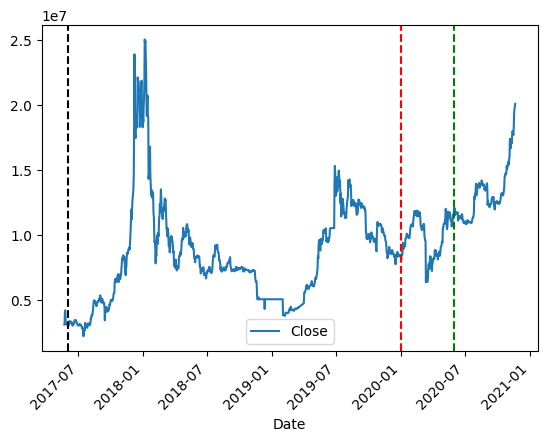

In [7]:
ax = df_close.plot(rot=45)
ax.axvline("2017-06-01", linestyle="--", c="black")
ax.axvline("2020-01-01", linestyle="--", c="red")
ax.axvline("2020-06-01", linestyle="--", c="green")

In [8]:
df_train = df_close[
  (df_close.index >= "2017-06-01")&(df_close.index < "2020-01-01")
]
print(df_train[:5])

              Close
Date               
2017-06-01  3142000
2017-06-02  3169000
2017-06-03  3110000
2017-06-04  3061000
2017-06-05  3188000


In [9]:
scaler = MinMaxScaler()
data = scaler.fit_transform(df_train[:5])
data

array([[0.63779528],
       [0.8503937 ],
       [0.38582677],
       [0.        ],
       [1.        ]])

In [10]:
scaler.inverse_transform(data)

array([[3142000.],
       [3169000.],
       [3110000.],
       [3061000.],
       [3188000.]])

In [11]:
class BitcoinDataset(Dataset):
  def __init__(self, split="train", seq_len=4):
    self.split = split
    self.seq_len = seq_len

    self.date_range = {
      "train": ["2017-06-01", "2020-01-01"],
      "val": ["2020-01-01", "2020-06-01"],
      "test": ["2020-06-01", "2020-11-21"]
    }

    self.data = self._load_data(self.date_range[self.split])
    self.data, self.labels = self._transform(self.data, self.seq_len)

  def _load_data(self, date_range):
    df = pd.read_csv("/kaggle/working/Bithumb_BTCKRW_d.csv", skiprows=1)
    df['Date'] = df['Date'].apply(pd.Timestamp)
    df = df.sort_values('Date')
    df.set_index('Date', inplace=True)

    df_close = df.loc[:, ["Close"]]
    df = df_close[
      (df_close.index >= date_range[0])&(df_close.index < date_range[1])
    ]

    self.scaler = MinMaxScaler()
    data = self.scaler.fit_transform(df)
    return data

  def _transform(self, data, seq_len):
    x, y = [], []

    for i in range(len(data) - seq_len - 1):
      x_i = data[i:i+seq_len]
      y_i = data[i+1:i+seq_len+1]
      x.append(x_i)
      y.append(y_i)

    x_tensor = torch.FloatTensor(x)
    y_tensor = torch.FloatTensor(y)

    return x_tensor, y_tensor

  def __getitem__(self, i):
    return self.data[i], self.labels[i]

  def __len__(self):
    return len(self.data)

In [12]:
trainset = BitcoinDataset()
valset = BitcoinDataset(split="val")
testset = BitcoinDataset(split="test")

print(len(trainset), len(valset), len(testset))

927 147 168


In [13]:
def plot_sequence(x, y):
  plt.ylabel("Scaled Close")
  plt.xlabel("Time Bars")
  plt.plot(range(len(x)), x, color='r', label='Features')
  plt.plot(range(1, len(x)+1), y, color='b', linestyle='--', label='Target')
  plt.legend()

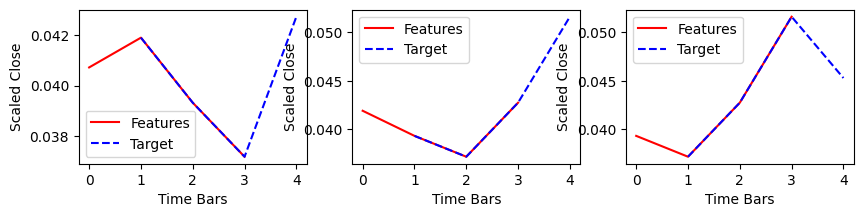

In [14]:
plt.figure(figsize=(10,2))
for i, (x, y) in enumerate(trainset):
  plt.subplot(1, 3, i+1)
  plot_sequence(x, y)

  if i == 2:
    break

## 1.4 LSTM 모델



In [15]:
model = nn.LSTM(4, 4)
summary(model, (1, 4))

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 4]                    160
Total params: 160
Trainable params: 160
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [16]:
output, (hidden_state, cell_state) = model(torch.randn((1,4)).to(device))
print(output)
print(hidden_state)
print(cell_state)

tensor([[ 0.0762,  0.0243, -0.0959,  0.0190]], device='cuda:0',
       grad_fn=<SqueezeBackward1>)
tensor([[ 0.0762,  0.0243, -0.0959,  0.0190]], device='cuda:0',
       grad_fn=<SqueezeBackward1>)
tensor([[ 0.2166,  0.0501, -0.2409,  0.0480]], device='cuda:0',
       grad_fn=<SqueezeBackward1>)


## 1.5 모델 학습



In [17]:
def train(model, dataloader, criterion, optimizer, epoch, device):
  model.train()

  running_loss = 0

  with tqdm(dataloader) as pbar:
    for i, (features, targets) in enumerate(pbar):
      features = features.to(device)
      targets = targets.to(device)

      optimizer.zero_grad()

      outputs, _ = model(features)
      loss = criterion(outputs, targets)

      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      pbar.set_postfix(loss=loss.item())

  return running_loss/len(dataloader)

In [18]:
def validation(model, dataloader, criterion, epoch, device):
  model.eval()

  running_loss = 0

  with tqdm(dataloader) as pbar:
    with torch.no_grad():
      for i, (features, targets) in enumerate(pbar):
        features = features.to(device)
        targets = targets.to(device)

        outputs, _ = model(features)
        loss = criterion(outputs, targets)

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

  return running_loss/len(dataloader)

In [19]:
EPOCH = 60
BATCH_SIZE = 128
NUM_WORKERS = 2
LR = 0.1

trainset = BitcoinDataset()
valset = BitcoinDataset(split="val")
testset = BitcoinDataset(split="test")

train_loader = DataLoader(
  dataset=trainset,
  batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
  dataset=valset,
  batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)
test_loader = DataLoader(
  dataset=testset,
  batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)

# Model
# model = nn.LSTM(4, 4)
# input_size=1임에도 불구하고 input_size=4로 LSTM을 선언해서 오류
# LSTM 입력 차원을 1로 수정
model = nn.LSTM(1, 4)

# Optimizer, Loss, Scheduler
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.2)

model = model.to(device)
criterion = criterion.to(device)

# Start Training
min_loss = 999
for epoch in range(EPOCH):
  print("LR:", scheduler.get_last_lr())

  tloss = train(model, train_loader, criterion, optimizer, epoch, device)
  vloss = validation(model, val_loader, criterion, epoch, device)
  print(f'[{epoch}/{EPOCH}] valid loss: {vloss:.4f}\n')
  scheduler.step()

  if vloss < min_loss:
    print(f"Update Best Model: {vloss}")
    torch.save(model.state_dict(), "best.pth")
    min_loss = vloss

LR: [0.1]


100%|██████████| 2/2 [00:00<00:00, 29.17it/s, loss=0.415]


[0/60] valid loss: 0.3082

Update Best Model: 0.3082193359732628
LR: [0.1]


100%|██████████| 2/2 [00:00<00:00, 28.89it/s, loss=0.211]


[1/60] valid loss: 0.1508

Update Best Model: 0.15082623809576035
LR: [0.1]


...

[57/60] valid loss: 0.0126

Update Best Model: 0.012554612709209323
LR: [0.004000000000000001]


100%|██████████| 2/2 [00:00<00:00, 27.44it/s, loss=0.0175]


[58/60] valid loss: 0.0125

Update Best Model: 0.012544096913188696
LR: [0.004000000000000001]


100%|██████████| 2/2 [00:00<00:00, 26.04it/s, loss=0.0175]

[59/60] valid loss: 0.0125

Update Best Model: 0.012533487286418676


## 1.6 추론



In [20]:
def test(model, dataloader, device):
  model.eval()

  predicts = []

  with tqdm(dataloader) as pbar:
    with torch.no_grad():
      for i, (features, _) in enumerate(pbar):
        features = features.to(device)

        outputs, _ = model(features)
        y_pred = outputs[:, -1, 0]  # (batch_size,) 형태로 1차원 만들기
        predicts.append(y_pred)

  return torch.cat(predicts)

In [21]:
def show_plot(model, dataloader, device):

    actual = dataloader.dataset.data[:, -1].squeeze() # shape이 (N, 1)이라면 1차원으로 변환
    predicts = test(model, dataloader, device).cpu().numpy()

    # 예: hidden_state[0] 사용
    if predicts.ndim == 2:
        predicts = predicts[:, 0] # 또는 평균값: predicts.mean(axis=1)

    # Pandas의 DataFrame 생성 시 각 column은 반드시 1차원 배열
    df = pd.DataFrame({"actual": actual, "predicted": predicts})

    # 역정규화
    df["actual"] = scaler.inverse_transform(df["actual"].values.reshape(-1, 1)).reshape(-1)
    df["predicted"] = scaler.inverse_transform(df["predicted"].values.reshape(-1, 1)).reshape(-1)
    df.plot(figsize=(14,5))

In [22]:
model = nn.LSTM(1, 4).to(device)
model.load_state_dict(torch.load("/kaggle/working/best.pth"))

<All keys matched successfully>

100%|██████████| 8/8 [00:00<00:00, 94.66it/s]


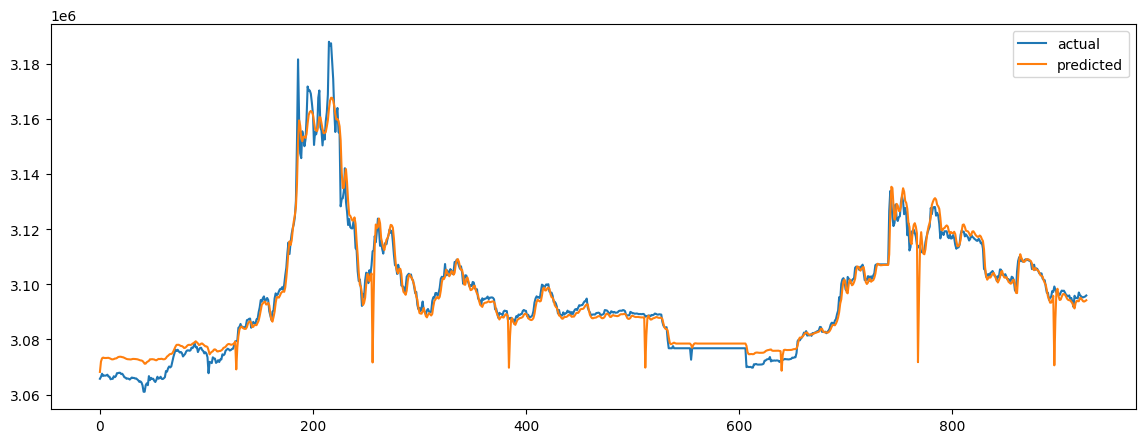

In [23]:
show_plot(model, train_loader, device)


100%|██████████| 2/2 [00:00<00:00, 29.32it/s]


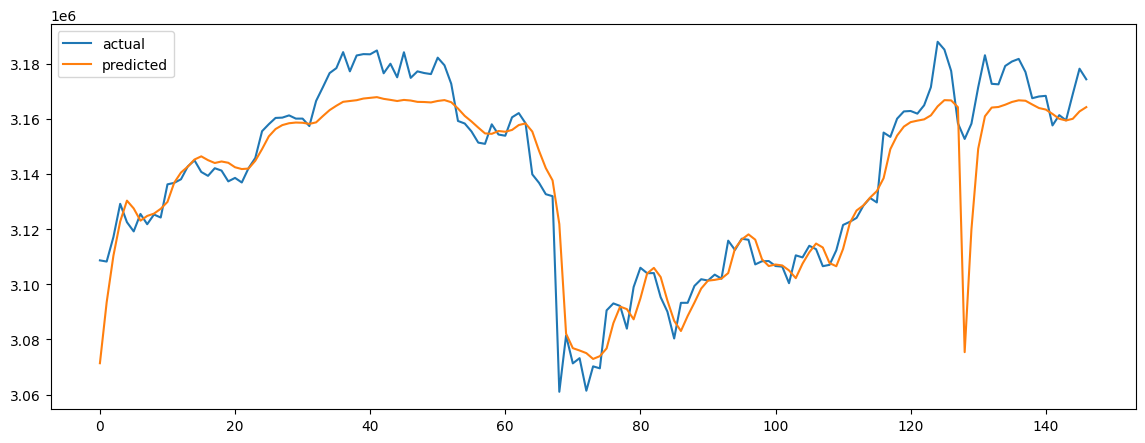

In [24]:
show_plot(model, val_loader, device)


100%|██████████| 2/2 [00:00<00:00, 26.50it/s]


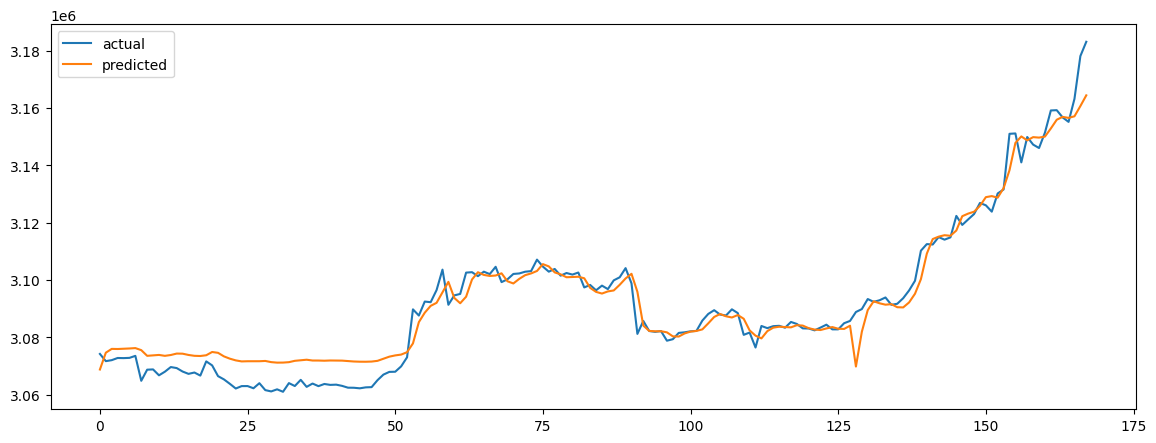

In [25]:
show_plot(model, test_loader, device)
